# LaCAM discrete-time survival models

A single XGBoost classifier estimates the discrete hazard $h_j(c)=P(R_c=j\mid R_c>j-1,x_c)$. The cumulative probability is $1-\prod_{j=1}^t(1-h_j(c))$. M1 is trained on MovingAI and M2 on POGEMA; termination beyond 40 seconds is censored at the modelling horizon.

In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import (
    GroupShuffleSplit, StratifiedGroupKFold,
)
from xgboost import XGBClassifier

from mapf_anytime.features import STATIC_FEATURES

SEED = 42
JOBS = -1
HORIZON = 40
FOLDS = 5
MOVINGAI_SPLIT = "random-instance"  # "fixed-map" or "random-instance"
EVALUATION_HORIZONS = [1, 5, 10, 20, 40]
PERMUTATION_REPEATS = 5
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
MOVINGAI_DATASET = ROOT / "datasets/movingai_final.csv"
POGEMA_DATASET = ROOT / "datasets/pogema_final.csv"
FEATURES = [*STATIC_FEATURES, "time_step"]
MOVINGAI_TEST_MAPS = (
    (
        "empty-8-8.map", "random-32-32-10.map",
        "ht_chantry.map", "maze-128-128-1.map", "ht_mansion_n.map",
        "warehouse-20-40-10-2-2.map", "Paris_1_256.map",
    ),
    (
        "empty-16-16.map", "empty-32-32.map",
        "den312d.map", "room-64-64-16.map",
        "warehouse-20-40-10-2-1.map", "Berlin_1_256.map", "orz900d.map",
    ),
    (
        "maze-32-32-4.map", "random-32-32-20.map",
        "random-64-64-20.map", "warehouse-10-20-10-2-1.map",
        "lak303d.map", "brc202d.map", "Boston_0_256.map",
    ),
    (
        "room-32-32-4.map", "random-64-64-10.map",
        "warehouse-10-20-10-2-2.map", "maze-128-128-2.map",
        "ost003d.map", "den520d.map",
    ),
    (
        "maze-32-32-2.map", "empty-48-48.map", "room-64-64-8.map",
        "lt_gallowstemplar_n.map", "maze-128-128-10.map",
        "w_woundedcoast.map",
    ),
)

## Data and censoring

,seed runs,base instances,maps,terminated,censored,median runtime,90th percentile runtime
dataset,,,,,,,
MovingAI,19800,4950,33,17488,2312,2.289,40.000
POGEMA,19836,4959,4959,18377,1459,3.240,33.618


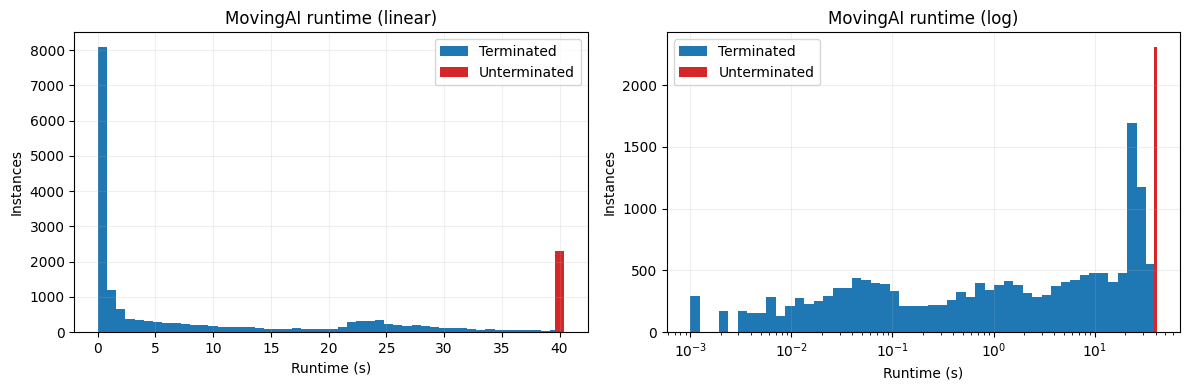

In [16]:
def load_instances(path):
    raw = pd.read_csv(path)
    columns = [
        "instance_id", "map_name", "lacam_seed", "lacam_solved",
        "lacam_runtime_seconds", *STATIC_FEATURES,
    ]
    missing = sorted(set(columns) - set(raw))
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    keys = ["instance_id", "lacam_seed"]
    agreement = raw.groupby(keys)[[column for column in columns if column not in keys]].nunique(dropna=False).max()
    if agreement.gt(1).any():
        raise ValueError("Seed-run fields differ across neighbourhood rows")
    data = raw.sort_values([*keys, "lns_neighborhood_size"]).drop_duplicates(keys).copy()
    data[columns[2:]] = data[columns[2:]].apply(pd.to_numeric, errors="coerce")
    data = data.dropna(subset=columns[2:]).reset_index(drop=True)
    data["event_observed"] = (
        data.lacam_solved.astype(int).eq(1)
        & data.lacam_runtime_seconds.le(HORIZON)
    )
    data["event_step"] = np.ceil(data.lacam_runtime_seconds).astype(int).clip(1, HORIZON)
    data["observed_step"] = np.where(data.event_observed, data.event_step, HORIZON)
    return data

movingai = load_instances(MOVINGAI_DATASET)
pogema = load_instances(POGEMA_DATASET)
summary = []
for name, data in [("MovingAI", movingai), ("POGEMA", pogema)]:
    summary.append({
        "dataset": name, "seed runs": len(data),
        "base instances": data.instance_id.nunique(), "maps": data.map_name.nunique(),
        "terminated": int(data.event_observed.sum()),
        "censored": int((~data.event_observed).sum()),
        "median runtime": data.lacam_runtime_seconds.median(),
        "90th percentile runtime": data.lacam_runtime_seconds.quantile(0.9),
    })
display(pd.DataFrame(summary).set_index("dataset").round(3))

def plot_runtime_distributions(name, data):
    terminated = data.loc[data.event_observed, "lacam_runtime_seconds"]
    censored = int((~data.event_observed).sum())
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(terminated, bins=50, label="Terminated")
    axes[0].bar(HORIZON, censored, width=0.8, color="tab:red", label="Unterminated")
    axes[1].hist(terminated, bins=np.logspace(-3, np.log10(HORIZON), 50), label="Terminated")
    axes[1].bar(HORIZON, censored, width=2, color="tab:red", label="Unterminated")
    axes[1].set_xscale("log")
    for column, scale in enumerate(["linear", "log"]):
        axes[column].set(
            title=f"{name} runtime ({scale})", xlabel="Runtime (s)", ylabel="Instances"
        )
        axes[column].grid(alpha=0.2)
        axes[column].legend()
    plt.tight_layout()
    plt.show()

plot_runtime_distributions("MovingAI", movingai)

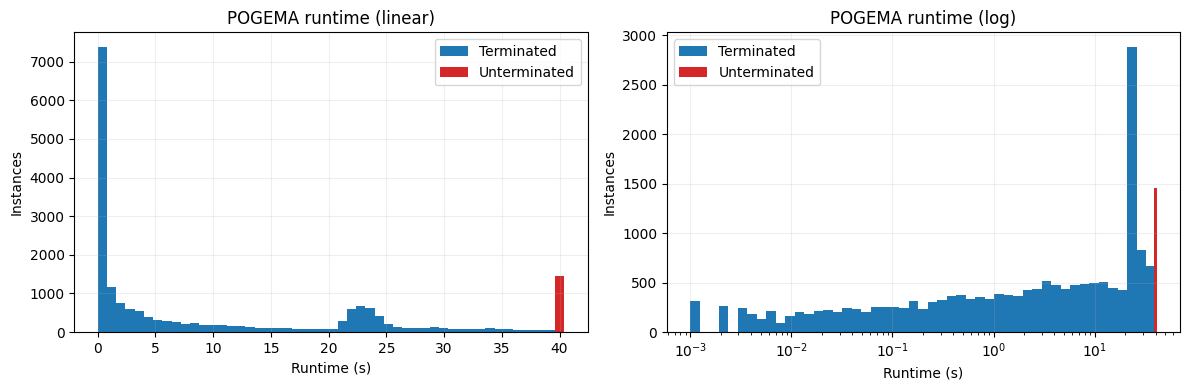

In [17]:
plot_runtime_distributions("POGEMA", pogema)

## Shared fixed parameters

Both datasets use the same fixed XGBoost parameters below. These are established before any model fitting or evaluation; no hyperparameter search is performed.

In [18]:
BASE_PARAMETERS = dict(
    n_estimators=1000, learning_rate=0.03, max_depth=7, min_child_weight=10,
    subsample=0.85, colsample_bytree=0.85, reg_alpha=0.1, reg_lambda=5.0,
)
HYP_1 = dict(BASE_PARAMETERS)
HYP_2 = dict(BASE_PARAMETERS)

COMMON_PARAMETERS = dict(
    objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", n_jobs=JOBS,
)

def expand(frame):
    counts = frame.observed_step.astype(int).to_numpy()
    rows = frame.loc[
        frame.index.repeat(counts), ["instance_id", *STATIC_FEATURES]
    ].reset_index(drop=True)
    rows["time_step"] = np.concatenate([np.arange(1, count + 1) for count in counts])
    target = np.zeros(len(rows), dtype=np.int8)
    endpoints = np.cumsum(counts) - 1
    target[endpoints[frame.event_observed.to_numpy()]] = 1
    rows["target"] = target
    return rows

def classifier(parameters, seed, early_stopping=True):
    options = {**COMMON_PARAMETERS, **parameters, "random_state": seed}
    if early_stopping:
        options["early_stopping_rounds"] = 75
    return XGBClassifier(**options)

def predict_curves(estimator, frame, permuted_feature=None, rng=None):
    rows = frame.loc[frame.index.repeat(HORIZON), list(STATIC_FEATURES)].reset_index(drop=True)
    rows["time_step"] = np.tile(np.arange(1, HORIZON + 1), len(frame))
    if permuted_feature == "time_step":
        rows.time_step = rng.permutation(rows.time_step.to_numpy())
    elif permuted_feature:
        rows[permuted_feature] = np.repeat(
            rng.permutation(frame[permuted_feature].to_numpy()), HORIZON
        )
    hazards = estimator.predict_proba(rows[FEATURES])[:, 1].reshape(len(frame), HORIZON)
    return 1 - np.cumprod(1 - np.clip(hazards, 1e-9, 1 - 1e-9), axis=1)

def empirical_cdf(frame):
    survival, values = 1.0, []
    for second in range(1, HORIZON + 1):
        at_risk = (frame.observed_step >= second).sum()
        events = (frame.event_observed & frame.event_step.eq(second)).sum()
        if at_risk:
            survival *= 1 - events / at_risk
        values.append(1 - survival)
    return np.asarray(values)

def average_baseline(training, size):
    return np.tile(empirical_cdf(training), (size, 1))

def out_of_fold_baseline(data, splits):
    prediction = np.full((len(data), HORIZON), np.nan)
    for training, test in splits:
        prediction[test] = average_baseline(data.iloc[training], len(test))
    return prediction

def horizon_metrics(frame, cumulative, baseline=None):
    event = frame.event_observed.to_numpy()
    event_step = frame.event_step.to_numpy()
    rows = []
    for second in EVALUATION_HORIZONS:
        outcome = (event & (event_step <= second)).astype(int)
        probability = cumulative[:, second - 1]
        row = {
            "seconds": second,
            "Brier score": brier_score_loss(outcome, probability),
            "ROC AUC": roc_auc_score(outcome, probability) if np.unique(outcome).size == 2 else np.nan,
        }
        if baseline is not None:
            row["Baseline Brier score"] = brier_score_loss(
                outcome, baseline[:, second - 1]
            )
        rows.append(row)
    return pd.DataFrame(rows)

def validation_split(development, group_column, seed):
    return next(GroupShuffleSplit(
        n_splits=1, test_size=0.2, random_state=seed
    ).split(development, groups=development[group_column]))


def cross_validate(data, splits, parameters, validation_group):
    out_of_fold = np.full((len(data), HORIZON), np.nan)
    models, summaries = [], []
    for fold, (development_index, test_index) in enumerate(splits, start=1):
        assert set(data.iloc[development_index].instance_id).isdisjoint(data.iloc[test_index].instance_id)
        development = data.iloc[development_index]
        train_relative, validation_relative = validation_split(
            development, validation_group, SEED + fold
        )
        train = development.iloc[train_relative]
        validation = development.iloc[validation_relative]
        train_rows, validation_rows = expand(train), expand(validation)
        estimator = classifier(parameters, SEED + fold)
        estimator.fit(
            train_rows[FEATURES], train_rows.target,
            eval_set=[(validation_rows[FEATURES], validation_rows.target)],
            verbose=False,
        )
        out_of_fold[test_index] = predict_curves(estimator, data.iloc[test_index])
        models.append((estimator, test_index))
        summaries.append({
            "fold": fold, "train instances": len(train),
            "validation instances": len(validation), "test instances": len(test_index),
            "best iteration": estimator.best_iteration,
        })
    assert np.isfinite(out_of_fold).all()
    return out_of_fold, models, pd.DataFrame(summaries)

def fold_metrics(data, cumulative, baseline, splits):
    rows = []
    for fold, (_, test) in enumerate(splits, start=1):
        table = horizon_metrics(data.iloc[test], cumulative[test], baseline[test])
        table["fold"] = fold
        rows.append(table)
    return pd.concat(rows, ignore_index=True)

## M1: MovingAI five-fold evaluation

`MOVINGAI_SPLIT` selects random instance-disjoint folds (currently active) or the fixed map-disjoint folds balanced for map type, traversable-cell scale, and retained row count.

In [19]:
def fixed_map_splits(data, test_map_folds=MOVINGAI_TEST_MAPS):
    assigned = [map_name for fold_maps in test_map_folds for map_name in fold_maps]
    if len(assigned) != len(set(assigned)):
        raise ValueError("A MovingAI map is assigned to more than one fold")
    observed, configured = set(data.map_name.astype(str)), set(assigned)
    if observed != configured:
        raise ValueError(
            f"MovingAI fold mismatch; missing={sorted(observed - configured)}, "
            f"unused={sorted(configured - observed)}"
        )
    for fold_maps in test_map_folds:
        is_test = data.map_name.isin(fold_maps).to_numpy()
        yield np.flatnonzero(~is_test), np.flatnonzero(is_test)

if MOVINGAI_SPLIT not in {"fixed-map", "random-instance"}:
    raise ValueError(f"Unknown MovingAI split: {MOVINGAI_SPLIT}")
if MOVINGAI_SPLIT == "fixed-map":
    m1_splits = list(fixed_map_splits(movingai))
    m1_validation_group = "map_name"
else:
    m1_splits = list(StratifiedGroupKFold(
        FOLDS, shuffle=True, random_state=SEED
    ).split(movingai, movingai.event_observed, groups=movingai.instance_id))
    m1_validation_group = "instance_id"
m1_oof, m1_models, m1_summary = cross_validate(
    movingai, m1_splits, HYP_1, validation_group=m1_validation_group
)
m1_baseline = out_of_fold_baseline(movingai, m1_splits)
m1_metrics = fold_metrics(movingai, m1_oof, m1_baseline, m1_splits)
display(m1_summary.set_index("fold"))
display(m1_metrics.groupby("seconds")[[
    "Brier score", "Baseline Brier score", "ROC AUC"
]].agg(["mean", "std"]).round(4))

,train instances,validation instances,test instances,best iteration
fold,,,,
1,12672,3168,3960,430
2,12672,3168,3960,355
3,12668,3168,3964,383
4,12668,3168,3964,460
5,12676,3172,3952,464


Brier score         Baseline Brier score         ROC AUC        
               mean     std                 mean     std    mean     std
seconds                                                                 
1            0.0182  0.0036               0.2446  0.0009  0.9971  0.0010
5            0.0168  0.0025               0.2467  0.0014  0.9982  0.0004
10           0.0190  0.0017               0.2325  0.0031  0.9975  0.0005
20           0.0169  0.0043               0.2083  0.0022  0.9978  0.0009
40           0.0081  0.0013               0.1031  0.0043  0.9986  0.0006

## M2: POGEMA, five-fold random-instance evaluation

In [20]:
m2_splits = list(StratifiedGroupKFold(
    5, shuffle=True, random_state=SEED
).split(pogema, pogema.event_observed, groups=pogema.instance_id))
m2_oof, m2_models, m2_summary = cross_validate(
    pogema, m2_splits, HYP_2, validation_group="instance_id"
)
m2_baseline = out_of_fold_baseline(pogema, m2_splits)
m2_metrics = fold_metrics(pogema, m2_oof, m2_baseline, m2_splits)
display(m2_summary.set_index("fold"))
display(m2_metrics.groupby("seconds")[[
    "Brier score", "Baseline Brier score", "ROC AUC"
]].agg(["mean", "std"]).round(4))

,train instances,validation instances,test instances,best iteration
fold,,,,
1,12696,3176,3964,432
2,12704,3176,3956,429
3,12688,3172,3976,459
4,12704,3180,3952,187
5,12676,3172,3988,456


Brier score         Baseline Brier score         ROC AUC        
               mean     std                 mean     std    mean     std
seconds                                                                 
1            0.0112  0.0030               0.2381  0.0032  0.9989  0.0006
5            0.0152  0.0025               0.2476  0.0009  0.9982  0.0007
10           0.0180  0.0023               0.2342  0.0030  0.9977  0.0006
20           0.0166  0.0032               0.2097  0.0040  0.9971  0.0011
40           0.0187  0.0033               0.0682  0.0052  0.9840  0.0078

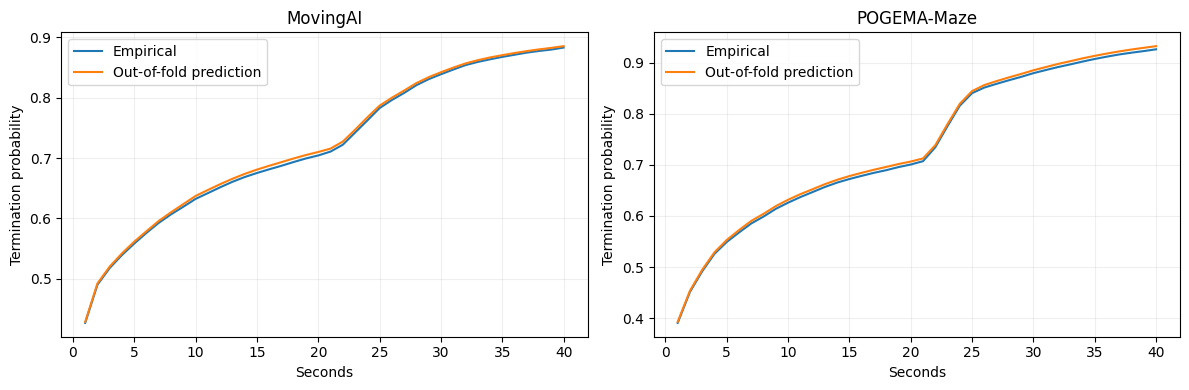

In [21]:
seconds = np.arange(1, HORIZON + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, name, data, prediction, baseline in [
    (axes[0], "MovingAI", movingai, m1_oof, m1_baseline),
    (axes[1], "POGEMA-Maze", pogema, m2_oof, m2_baseline),
]:
    axis.plot(seconds, empirical_cdf(data), label="Empirical")
    axis.plot(seconds, prediction.mean(axis=0), label="Out-of-fold prediction")
    axis.set(title=name, xlabel="Seconds", ylabel="Termination probability")
    axis.grid(alpha=0.2)
    axis.legend()
plt.tight_layout()
plt.show()

## Permutation importance

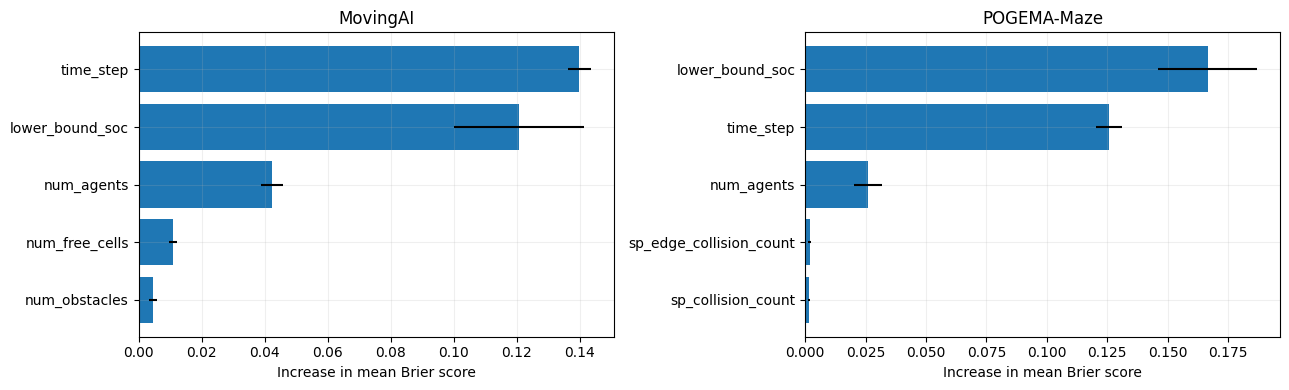

In [22]:
def mean_brier(data, cumulative):
    return horizon_metrics(data, cumulative)["Brier score"].mean()

def permutation_importance(data, models):
    rows = []
    for fold, (estimator, test_index) in enumerate(models, start=1):
        test = data.iloc[test_index]
        baseline = mean_brier(test, predict_curves(estimator, test))
        rng = np.random.default_rng(SEED + fold)
        for feature in FEATURES:
            for repeat in range(PERMUTATION_REPEATS):
                score = mean_brier(test, predict_curves(estimator, test, feature, rng))
                rows.append({
                    "fold": fold, "feature": feature,
                    "repeat": repeat + 1, "Brier increase": score - baseline,
                })
    scores = pd.DataFrame(rows)
    by_fold = scores.groupby(["fold", "feature"])["Brier increase"].mean()
    return by_fold.groupby("feature").agg(["mean", "std"]).sort_values("mean")

m1_importance = permutation_importance(movingai, m1_models)
m2_importance = permutation_importance(pogema, m2_models)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, name, importance in [
    (axes[0], "MovingAI", m1_importance),
    (axes[1], "POGEMA-Maze", m2_importance),
]:
    shown = importance.nlargest(5, "mean").sort_values("mean")
    axis.barh(shown.index, shown["mean"], xerr=shown["std"])
    axis.set(title=name, xlabel="Increase in mean Brier score")
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Five-fold cross-domain evaluation

For each source dataset, reuse the model trained for each of its five original folds and evaluate every model on the complete opposing dataset. Metrics are computed separately for each fold, then reported as their mean and sample standard deviation. Predictions are not averaged for metric computation. Each transfer uses the empirical average-CDF baseline from that fold's source development data, not from the target dataset.

In [23]:
def cross_domain_fold_metrics(target, models):
    if len(models) != 5:
        raise ValueError("Expected five fitted models")
    predictions, rows = [], []
    test_baseline = average_baseline(target, len(target))
    for fold, (estimator, _) in enumerate(models, start=1):
        prediction = predict_curves(estimator, target)
        table = horizon_metrics(target, prediction, test_baseline)
        table["fold"] = fold
        rows.append(table)
        predictions.append(prediction)
    return (
        pd.concat(rows, ignore_index=True),
        np.stack(predictions),
    )

m1_on_pogema_metrics, m1_on_pogema_by_fold = (
    cross_domain_fold_metrics(pogema, m1_models)
)
m2_on_movingai_metrics, m2_on_movingai_by_fold = (
    cross_domain_fold_metrics(movingai, m2_models)
)
cross_fold_metrics = pd.concat({
    "MovingAI → POGEMA": m1_on_pogema_metrics,
    "POGEMA → MovingAI": m2_on_movingai_metrics,
}, names=["transfer", "row"]).reset_index(level="row", drop=True).reset_index()
cross_metrics = (
    cross_fold_metrics.groupby(["transfer", "seconds"])[
        ["Brier score"]
    ].agg(["mean", "std"])
)
display(cross_metrics.round(4))

brier_transfer_summary = pd.DataFrame([
    {
        "transfer": "MovingAI → POGEMA",
        "in-domain mean Brier": m2_metrics["Brier score"].mean(),
        "cross-domain mean Brier": m1_on_pogema_metrics["Brier score"].mean(),
    },
    {
        "transfer": "POGEMA → MovingAI",
        "in-domain mean Brier": m1_metrics["Brier score"].mean(),
        "cross-domain mean Brier": m2_on_movingai_metrics["Brier score"].mean(),
    },
]).set_index("transfer")
brier_transfer_summary["Brier increase (%)"] = 100 * (
    brier_transfer_summary["cross-domain mean Brier"]
    / brier_transfer_summary["in-domain mean Brier"]
    - 1
)
overall_brier_increase_pct = 100 * (
    brier_transfer_summary["cross-domain mean Brier"].mean()
    / brier_transfer_summary["in-domain mean Brier"].mean()
    - 1
)
display(brier_transfer_summary.round(4))
print(
    "Average cross-domain Brier score increase "
    f"(both directions and all horizons): {overall_brier_increase_pct:.1f}%"
)
average_ood_brier = cross_fold_metrics["Brier score"].mean()
average_test_baseline_brier = cross_fold_metrics["Baseline Brier score"].mean()
average_baseline_reduction = average_test_baseline_brier - average_ood_brier
print(
    f"Average OOD Brier: model {average_ood_brier:.4f} vs test-set baseline "
    f"{average_test_baseline_brier:.4f}; reduction {average_baseline_reduction:.4f} "
    f"({100 * average_baseline_reduction / average_test_baseline_brier:.1f}%)."
)

Brier score        
                                 mean     std
transfer          seconds                    
MovingAI → POGEMA 1            0.0155  0.0004
                  5            0.0206  0.0012
                  10           0.0224  0.0007
                  20           0.0374  0.0031
                  40           0.0349  0.0013
POGEMA → MovingAI 1            0.0256  0.0010
                  5            0.0273  0.0017
                  10           0.0398  0.0018
                  20           0.0448  0.0020
                  40           0.0509  0.0018

,in-domain mean Brier,cross-domain mean Brier,Brier increase (%)
transfer,,,
MovingAI → POGEMA,0.0159,0.0262,64.1786
POGEMA → MovingAI,0.0158,0.0377,138.1954


Average cross-domain Brier score increase (both directions and all horizons): 101.0%
Average OOD Brier: model 0.0319 vs test-set baseline 0.2033; reduction 0.1713 (84.3%).


Brier score        
                                 mean     std
evaluation        seconds                    
MovingAI → POGEMA 1            0.0155  0.0004
                  5            0.0206  0.0012
                  10           0.0224  0.0007
                  20           0.0374  0.0031
                  40           0.0349  0.0013
POGEMA → POGEMA   1            0.0112  0.0030
                  5            0.0152  0.0025
                  10           0.0180  0.0023
                  20           0.0166  0.0032
                  40           0.0187  0.0033

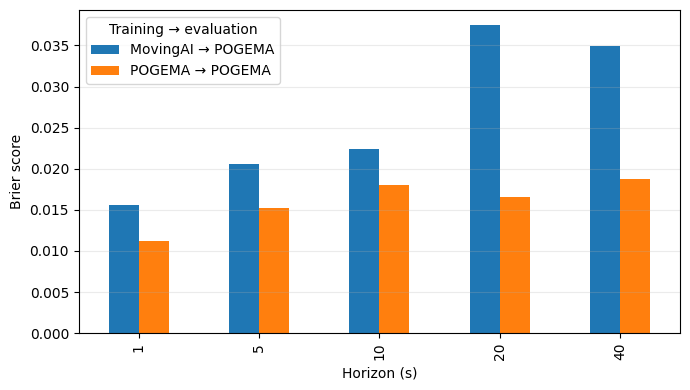

Brier score        
                                   mean     std
evaluation          seconds                    
MovingAI → MovingAI 1            0.0182  0.0036
                    5            0.0168  0.0025
                    10           0.0190  0.0017
                    20           0.0169  0.0043
                    40           0.0081  0.0013
POGEMA → MovingAI   1            0.0256  0.0010
                    5            0.0273  0.0017
                    10           0.0398  0.0018
                    20           0.0448  0.0020
                    40           0.0509  0.0018

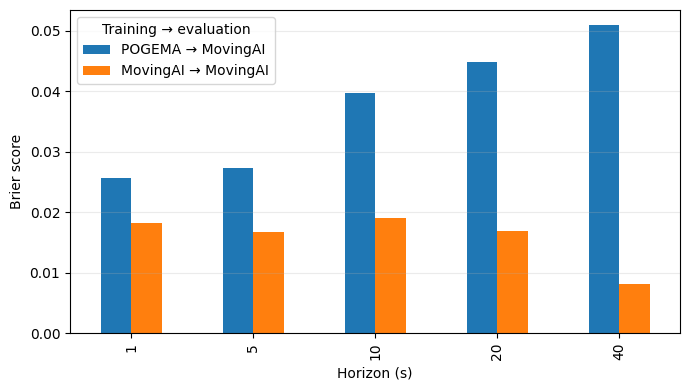

In [24]:
def plot_transfer_vs_in_domain(transfer, in_domain, labels):
    fold_data = pd.concat(
        {labels[0]: transfer, labels[1]: in_domain},
        names=["evaluation", "row"],
    ).reset_index(level="row", drop=True).reset_index()
    summary = (
        fold_data.groupby(["evaluation", "seconds"])[
            ["Brier score"]
        ].agg(["mean", "std"])
    )
    display(summary.round(4))

    metric_mean = summary[("Brier score", "mean")].unstack("evaluation")[list(labels)]
    axis = metric_mean.plot.bar(figsize=(7, 4))
    axis.set(xlabel="Horizon (s)", ylabel="Brier score")
    axis.grid(axis="y", alpha=0.25)
    axis.legend(title="Training → evaluation")
    plt.tight_layout()
    plt.show()

plot_transfer_vs_in_domain(
    m1_on_pogema_metrics, m2_metrics,
    ("MovingAI → POGEMA", "POGEMA → POGEMA"),
)
plot_transfer_vs_in_domain(
    m2_on_movingai_metrics, m1_metrics,
    ("POGEMA → MovingAI", "MovingAI → MovingAI"),
)

## Cross-domain CDF fit

Compare the fold models' mean predicted CDF with the empirical CDF of each target dataset. Prediction averaging here is only for this visualization; all reported cross-domain metrics are computed per fold before aggregation.

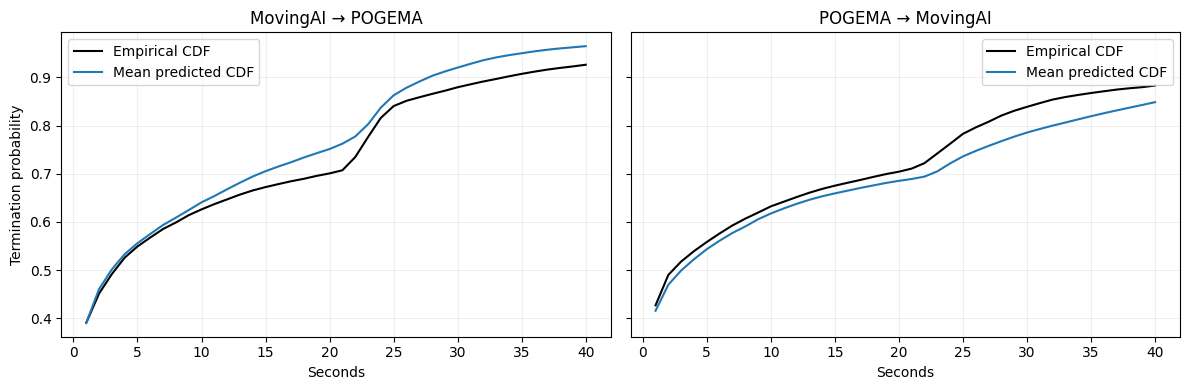

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, title, data, predictions in [
    (axes[0], "MovingAI → POGEMA", pogema, m1_on_pogema_by_fold),
    (axes[1], "POGEMA → MovingAI", movingai, m2_on_movingai_by_fold),
]:
    axis.plot(seconds, empirical_cdf(data), color="black", label="Empirical CDF")
    axis.plot(seconds, predictions.mean(axis=(0, 1)), label="Mean predicted CDF")
    axis.set(title=title, xlabel="Seconds")
    axis.grid(alpha=0.2)
    axis.legend()
axes[0].set_ylabel("Termination probability")
plt.tight_layout()
plt.show()